In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
from matplotlib import pyplot as plt
from typing import List, Literal
from math import ceil

import sys
import os
sys.path.append(os.path.abspath(".."))
from viral.constants import SERVER_PATH
from viral.models import BayesianDecodingConfig, GrosmarkConfig
from viral.sequence_utils import calculate_radon_replay, load_bayesian_cache

# to surpress RuntimeWarnings, ok here when lookin for parameters
import warnings
warnings.filterwarnings('ignore')

In [2]:
def plot_event(posterior_probability_matrix: np.ndarray, bayesian_config: BayesianDecodingConfig, grosmark_config: GrosmarkConfig, min_n_bin_perc: float, y_range: int, scoring: Literal["Grosmark", "Denovellis"] = "Grosmark", ax=None) -> plt.imshow:
    n_time, n_pos = posterior_probability_matrix.shape
    if ax is None:
        ax = plt.gca()

    im = ax.imshow(
        np.tile(posterior_probability_matrix.T, (2, 1)),
        vmin=0,
        vmax=np.max(posterior_probability_matrix) * 1.1,
        aspect="auto",
    )

    # trying the new Olafsdottir/Denovellis approach
    radon_replay = calculate_radon_replay(
        posterior_probability_matrix=posterior_probability_matrix,
        bayesian_config=bayesian_config,
        incorporate_nearby_positions=True,
        nearby_positions=30,
        min_n_bin_perc=min_n_bin_perc,
        scoring=scoring
    )

    x = np.array([radon_replay.point1x, radon_replay.point2x])
    y = np.array([radon_replay.point1y, radon_replay.point2y])

    ax.plot(x, y, "r--")
    ax.plot(x, y + y_range, "w")
    ax.plot(x, y - y_range, "w")

    offset = (bayesian_config.total_length * 100) / bayesian_config.bin_size_spatial
    ax.plot(x, y + offset, "r--")
    ax.plot(x, y + y_range + offset, "w")
    ax.plot(x, y - y_range + offset, "w")
    ax.plot(x, y - offset, "r--")
    ax.plot(x, y + y_range - offset, "w")
    ax.plot(x, y - y_range - offset, "w")

    ax.set_title(
        f"{radon_replay.slope_metres_per_sec:.2f} m/s ({radon_replay.replay_type} replay)"
    )

    ax.set_xlabel("Time (seconds)")
    xtick_bins = np.arange(0, n_time + 1, 15)
    xtick_labels = np.round(xtick_bins / 30, 2)
    ax.set_xticks(xtick_bins, xtick_labels)
    ax.set_ylabel("Position (centimetres)")
    ax.set_yticks(
        np.linspace(0, (n_pos * 2) - 1, 5),
        [
            str(x)
            for x in np.linspace(
                grosmark_config.start, grosmark_config.end * 2, 5
            ).astype(int)
        ],
    )
    ax.set_ylim((n_pos * 2) - 1, 0)
    ax.set_xlim(0, n_time - 1)
    return im

In [3]:
bayesian_config_post = BayesianDecodingConfig(
    epoch="post",
    # TODO: or is the 125 ms sigma also just offline and 1 s for online????
    sigma_offline=(125 / 1000) * 30,  # "125 ms Gaussian kernel"
    sigma_online=30,  # "1 s Gaussian kernel"
    # peak_threshold=3.5,
    peak_threshold=2,
    edge_threshold=1,
    # event_duration=(6, 30),
    # event_duration=(6, 120),
    # event_duration=(6, 90),
    event_duration=(6, 45),
    # bin_size_time_offline=2,
    bin_size_time_offline=10,
    bin_size_time_online=10,
    start_spatial=0,
    end_spatial=180,
    # bin_size_spatial=5,
    # bin_size_spatial=10,
    bin_size_spatial=15,
)
grosmark_config = GrosmarkConfig(
    bin_size=bayesian_config_post.bin_size_spatial,
    start=bayesian_config_post.start_spatial,
    end=bayesian_config_post.end_spatial,
)

# nearby_positions:
# - 30 cm (Olafsdottir et al. 2016, https://doi.org/10.1038/nn.4291)
# - 20 cm (Olafsdottir et al. 2015, https://doi.org/10.7554/eLife.06063)
# - 15 cm (Denovellis et al. 2021, https://doi.org/10.7554/eLife.64505)
nearby_positions = 30  # cm
y_range = int(
    nearby_positions / bayesian_config_post.bin_size_spatial
)
# min_n_bin_perc:
# - 100.0 percent (Grosmark et al. 2021, https://doi.org/10.1038/s41593-021-00920-7)
# - 1/3 = 33.33 percent (Olafsdottir et al. 2016 downloadable MATLAB code, https://doi.org/10.1038/nn.4291)
min_n_bin_perc = 100

In [4]:
def plot_several_events(example_ppms: List[np.ndarray], bayesian_config: BayesianDecodingConfig, grosmark_config: GrosmarkConfig, min_n_bin_perc: float, y_range: int, scoring: Literal["Grosmark", "Denovellis"] = "Grosmark") -> None:
    n = len(example_ppms)
    fig, axes = plt.subplots(2, ceil(n/2), figsize=(2*n,1.1*n))
    axes = axes.flatten()
    for idx, ppm in enumerate(example_ppms):
        im = plot_event(posterior_probability_matrix=ppm, bayesian_config=bayesian_config, grosmark_config=grosmark_config, min_n_bin_perc=min_n_bin_perc, y_range=y_range, ax=axes[idx], scoring=scoring)
        fig.colorbar(im, ax=axes[idx])
    plt.suptitle(f"scoring={scoring}, min_n_bin_perc={min_n_bin_perc}, y_range={y_range}", fontsize=20)
    plt.tight_layout()
    plt.show()
        

In [5]:
example_ppms: List[np.ndarray] = list()

cache_path = SERVER_PATH / "viral_caches" / "bayesian" / "JB036_2025-07-08_post_bin_size_spatial-15.npz"
for idx, event in enumerate(load_bayesian_cache(cache_path).decoded_events):
    # if idx in {22, 24, 29, 34, 39, 42, 66}: # did not have trouble with 22 or 34, so keeping 22 as positive control and rejecting 34 to make plot easier to read
    if idx in {22, 24, 29, 39, 42, 66}:
        example_ppms.append(event.posterior_probability_matrix)

# Grosmark scoring, varying min_perc of temporal bins crossed

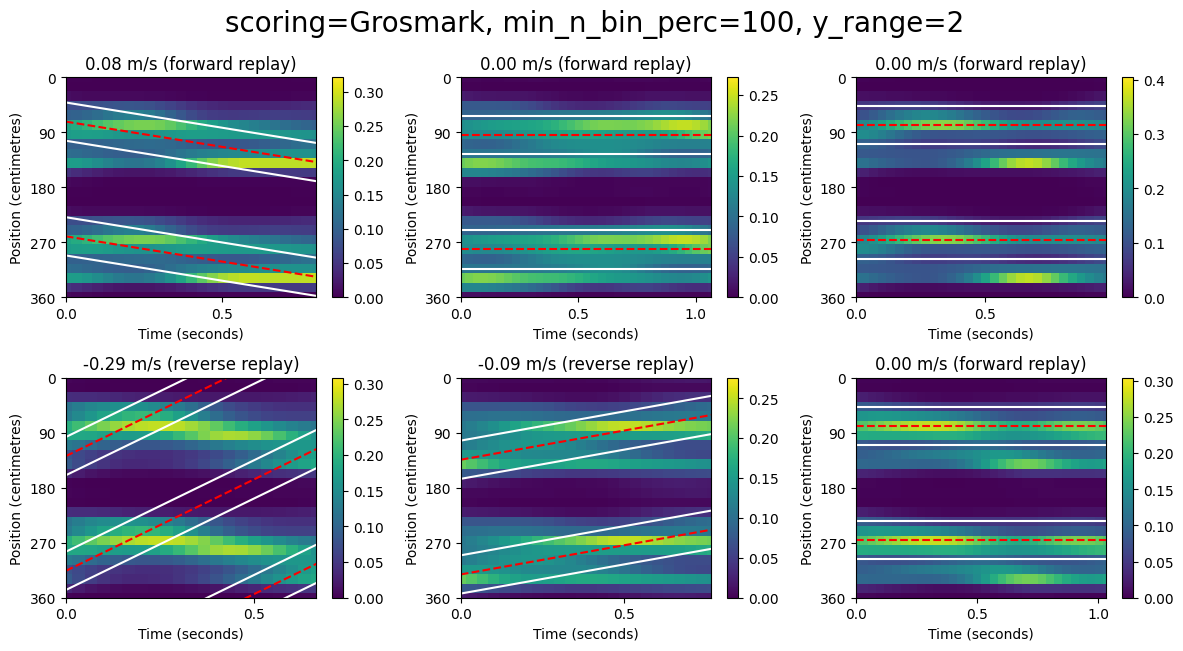

In [6]:
plot_several_events(example_ppms=example_ppms, bayesian_config=bayesian_config_post, grosmark_config=grosmark_config, min_n_bin_perc=100, y_range=y_range)

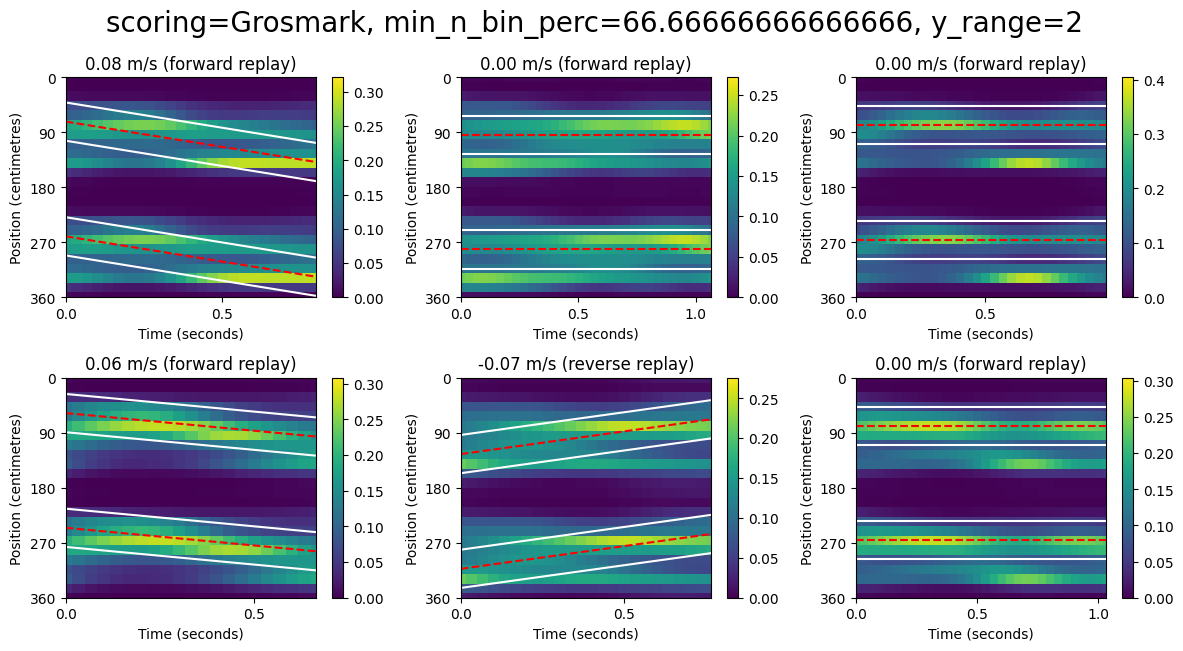

In [7]:
plot_several_events(example_ppms=example_ppms, bayesian_config=bayesian_config_post, grosmark_config=grosmark_config, min_n_bin_perc=(2/3)*100, y_range=y_range)

In [8]:
# -> looks like this works best

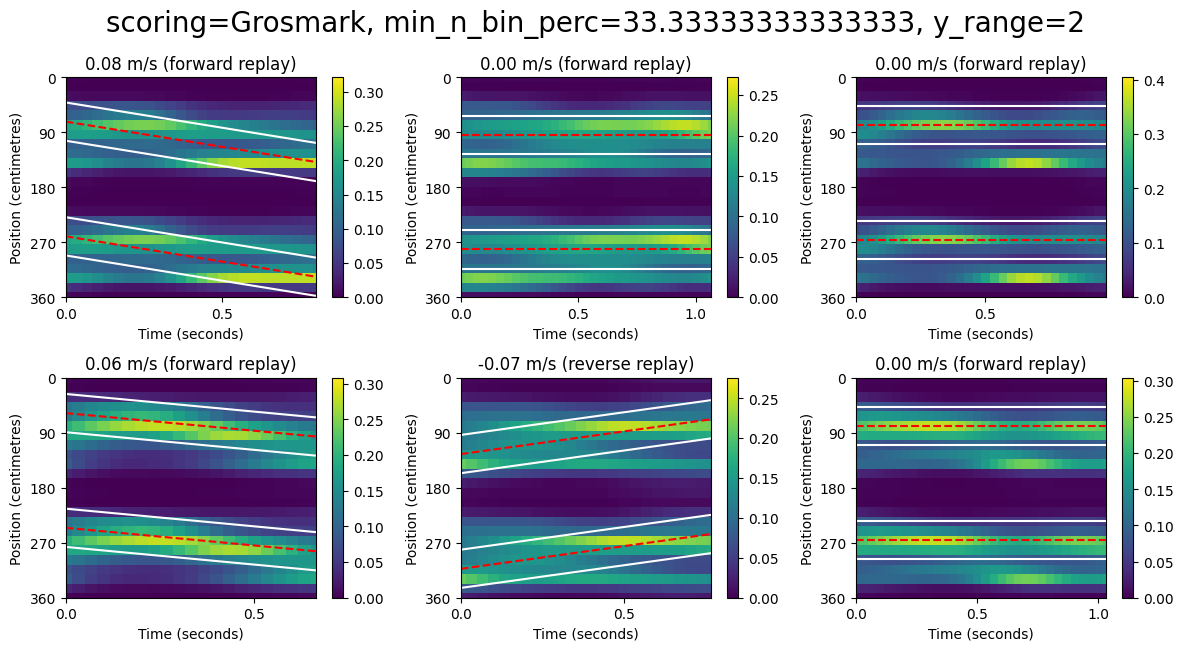

In [9]:
plot_several_events(example_ppms=example_ppms, bayesian_config=bayesian_config_post, grosmark_config=grosmark_config, min_n_bin_perc=(1/3)*100, y_range=y_range)

# Grosmark vs. Denovellis scoring

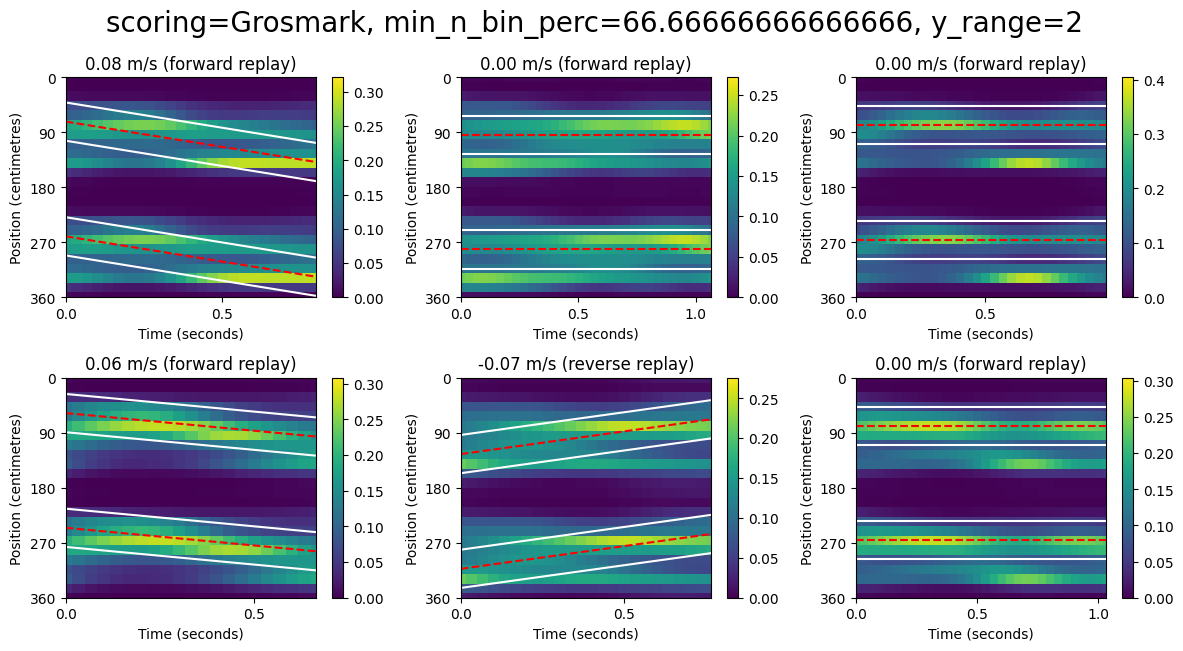

In [10]:
plot_several_events(example_ppms=example_ppms, bayesian_config=bayesian_config_post, grosmark_config=grosmark_config, min_n_bin_perc=(2/3)*100, y_range=y_range, scoring="Grosmark")

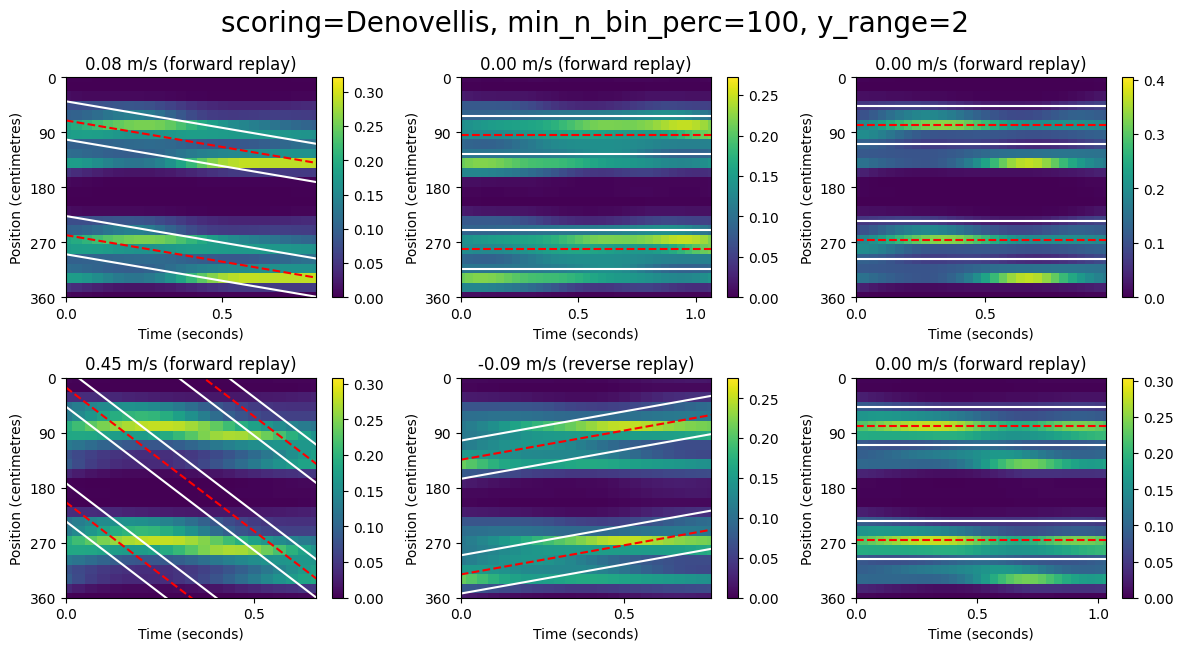

In [11]:
plot_several_events(example_ppms=example_ppms, bayesian_config=bayesian_config_post, grosmark_config=grosmark_config, min_n_bin_perc=100, y_range=y_range, scoring="Denovellis")

In [12]:
# for one fit, direction is opposite, but still, both equally bad for the bottom left

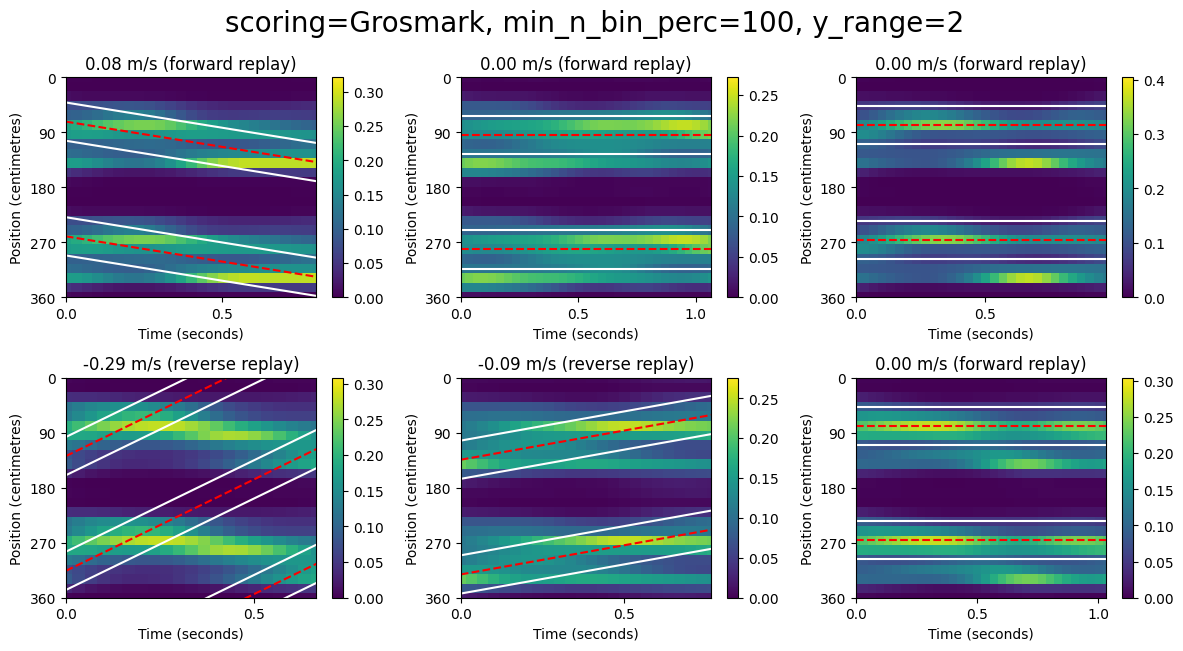

In [13]:
plot_several_events(example_ppms=example_ppms, bayesian_config=bayesian_config_post, grosmark_config=grosmark_config, min_n_bin_perc=100, y_range=y_range, scoring="Grosmark")

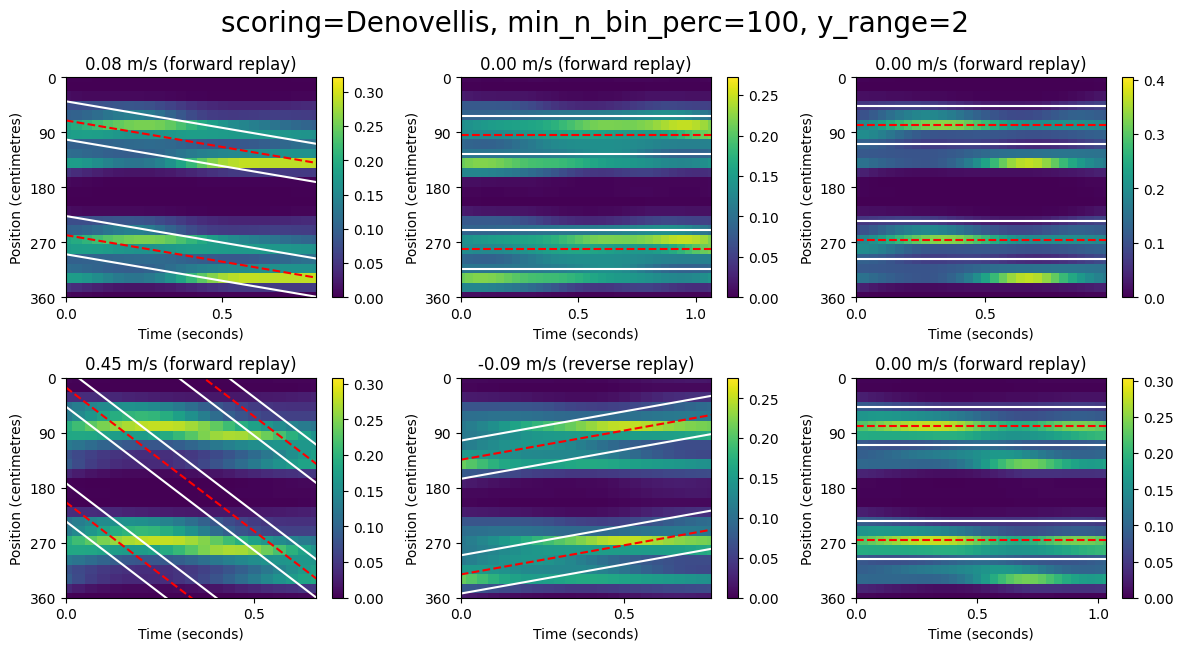

In [14]:
plot_several_events(example_ppms=example_ppms, bayesian_config=bayesian_config_post, grosmark_config=grosmark_config, min_n_bin_perc=100, y_range=y_range, scoring="Denovellis")

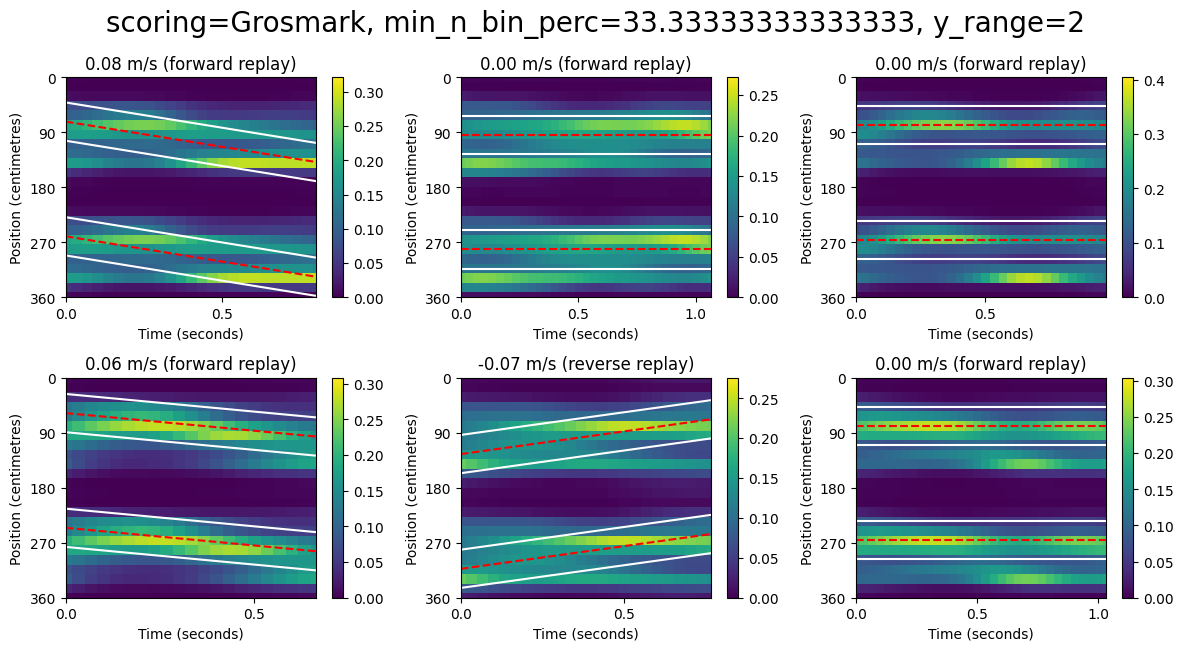

In [15]:
plot_several_events(example_ppms=example_ppms, bayesian_config=bayesian_config_post, grosmark_config=grosmark_config, min_n_bin_perc=(1/3)*100, y_range=y_range, scoring="Grosmark")

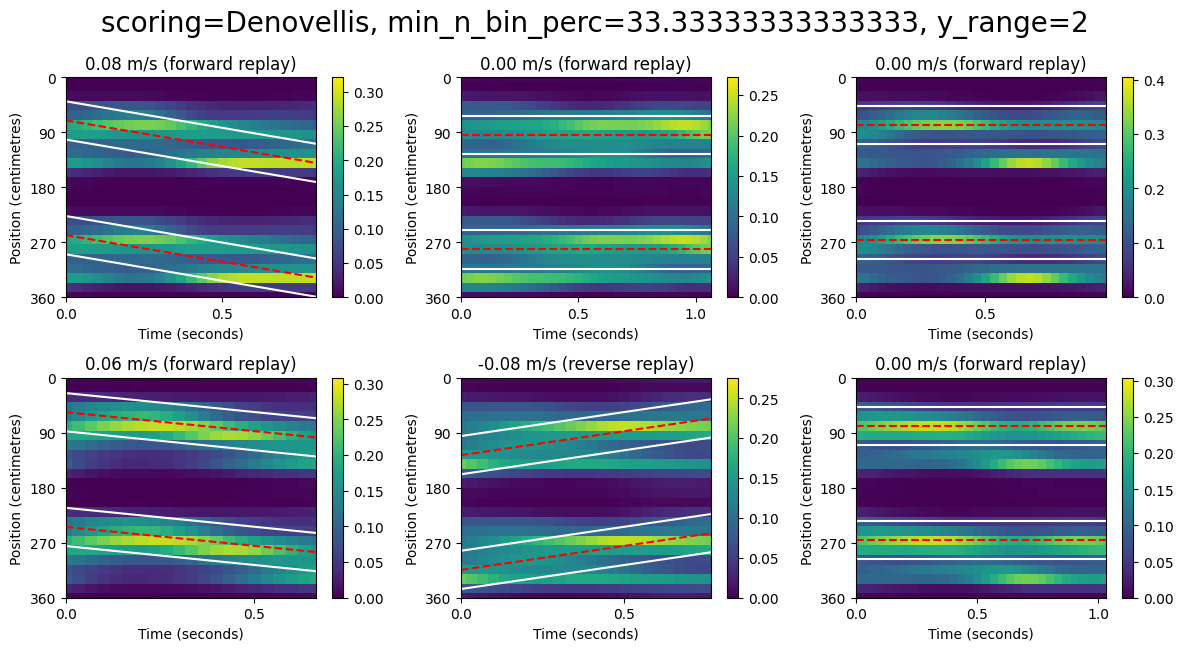

In [16]:
plot_several_events(example_ppms=example_ppms, bayesian_config=bayesian_config_post, grosmark_config=grosmark_config, min_n_bin_perc=(1/3)*100, y_range=y_range, scoring="Denovellis")

# Grosmark scoring, varying nearby_positions

In [17]:
nearby_positions = 15
y_range = int(
    nearby_positions / bayesian_config_post.bin_size_spatial
)

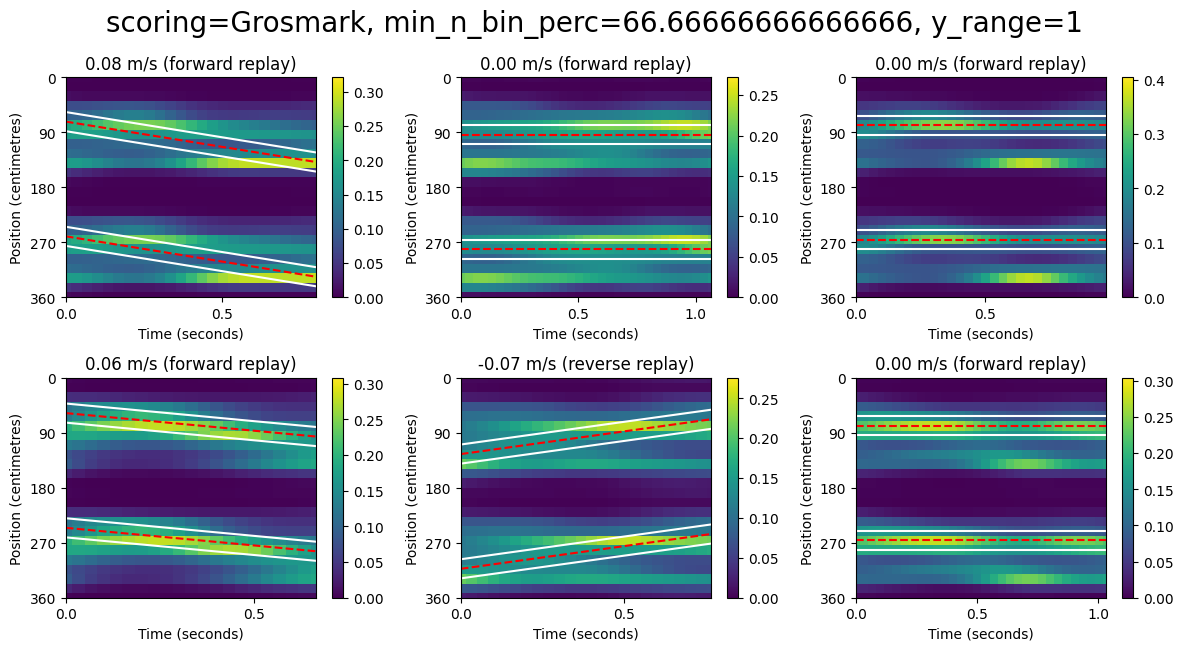

In [18]:
plot_several_events(example_ppms=example_ppms, bayesian_config=bayesian_config_post, grosmark_config=grosmark_config, min_n_bin_perc=(2/3)*100, y_range=y_range, scoring="Grosmark")

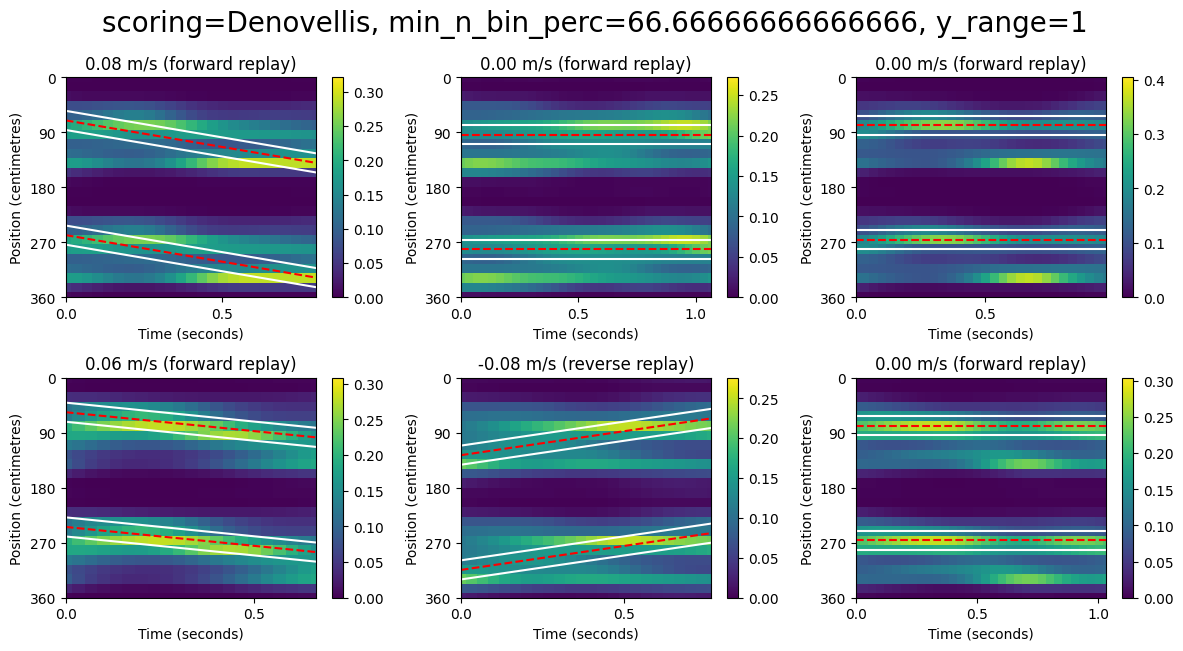

In [19]:
plot_several_events(example_ppms=example_ppms, bayesian_config=bayesian_config_post, grosmark_config=grosmark_config, min_n_bin_perc=(2/3)*100, y_range=y_range, scoring="Denovellis")

In [20]:
# at least for the well-suited 2/3 of temporal bins threshold, it still works with nearby 15 cms

In [21]:
nearby_positions = 20 # like Olafsdottir 2015
y_range = int(
    nearby_positions / bayesian_config_post.bin_size_spatial
)

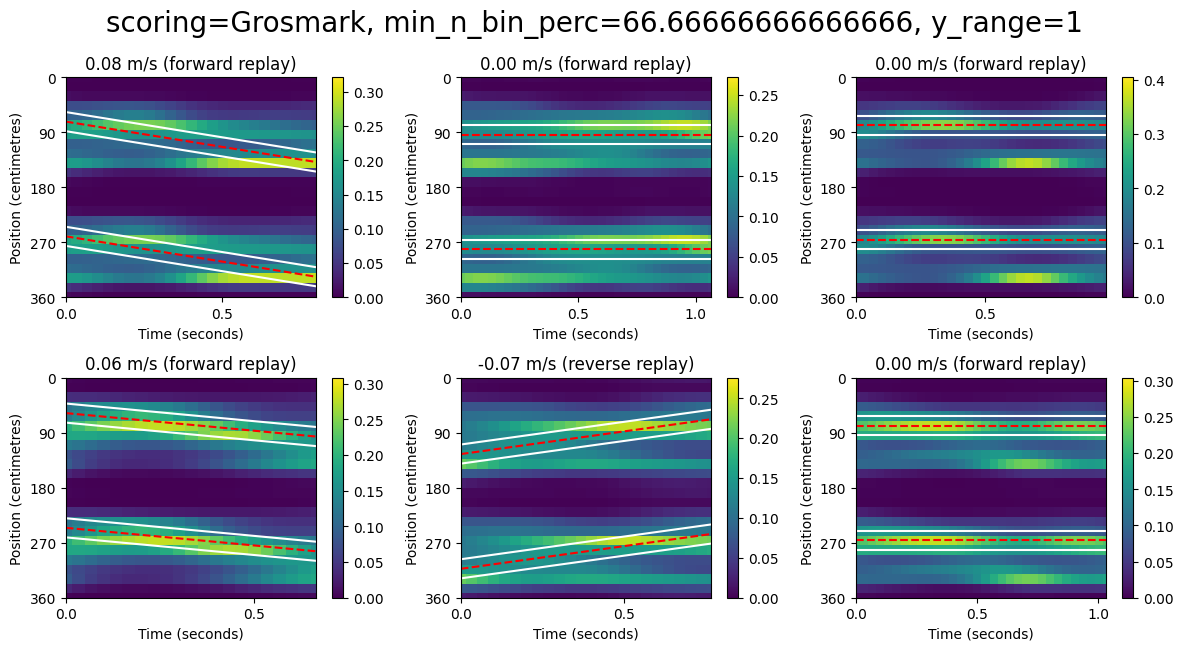

In [22]:
plot_several_events(example_ppms=example_ppms, bayesian_config=bayesian_config_post, grosmark_config=grosmark_config, min_n_bin_perc=(2/3)*100, y_range=y_range, scoring="Grosmark")

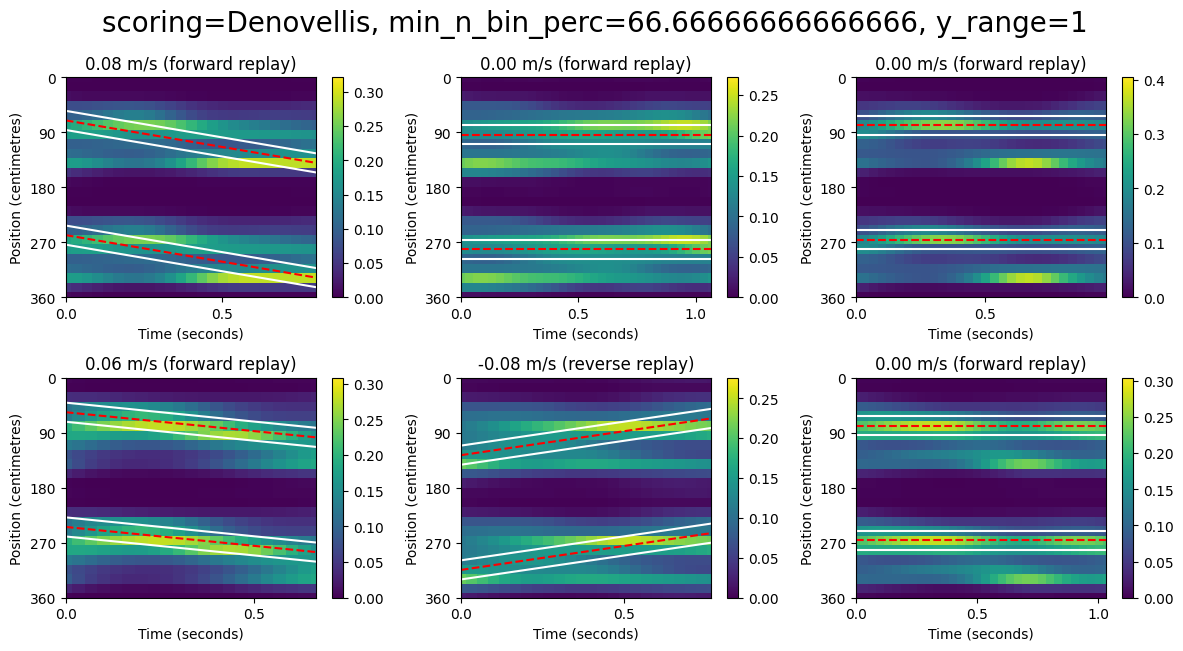

In [23]:
plot_several_events(example_ppms=example_ppms, bayesian_config=bayesian_config_post, grosmark_config=grosmark_config, min_n_bin_perc=(2/3)*100, y_range=y_range, scoring="Denovellis")